In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [30]:
df = pd.read_csv('C:/Users/medoc/OneDrive/Desktop/work/Machine/data/drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [32]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [33]:
print("Nulls:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

Nulls:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Duplicates: 0


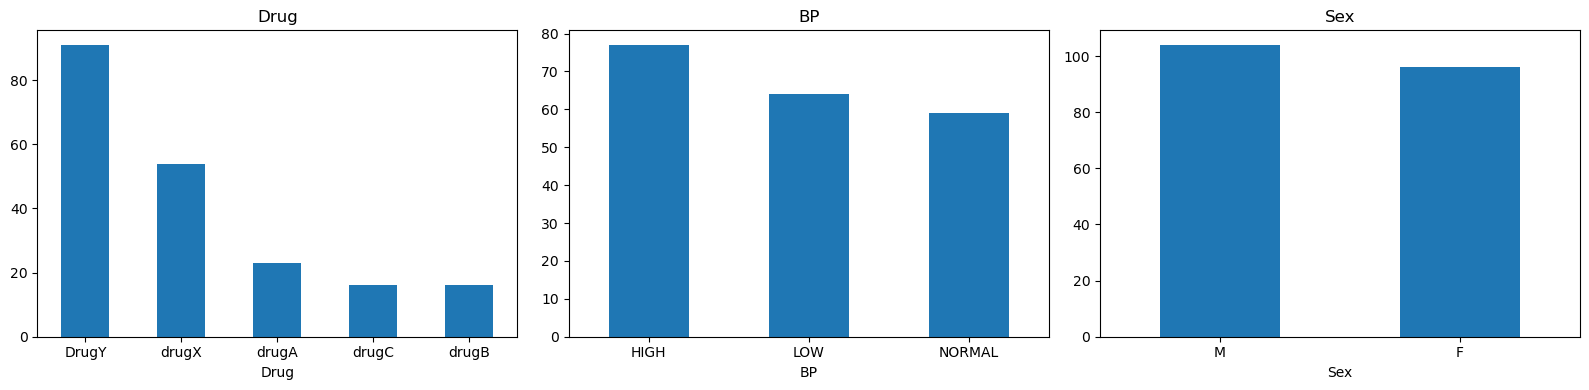

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Drug', 'BP', 'Sex']):
    df[col].value_counts().plot(kind='bar', ax=ax, rot=0)
    ax.set_title(col)
plt.tight_layout()
plt.show()

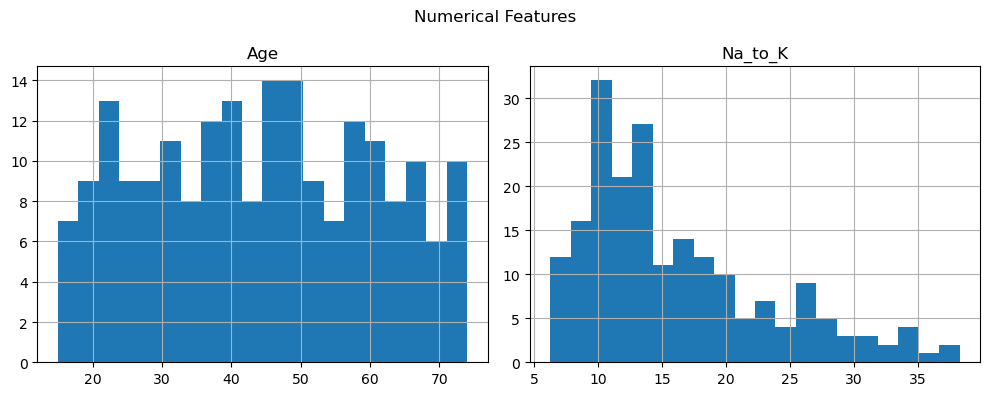

In [35]:
df[['Age', 'Na_to_K']].hist(bins=20, figsize=(10, 4))
plt.suptitle('Numerical Features')
plt.tight_layout()
plt.show()

In [36]:
for col in ['Sex', 'BP', 'Cholesterol']:
    df[col] = LabelEncoder().fit_transform(df[col])

le = LabelEncoder()
X = df.drop('Drug', axis=1)
y = le.fit_transform(df['Drug'])

print("Classes:", le.classes_)
print("X shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Classes: ['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']
X shape: (200, 5)
Train: 160  Test: 40


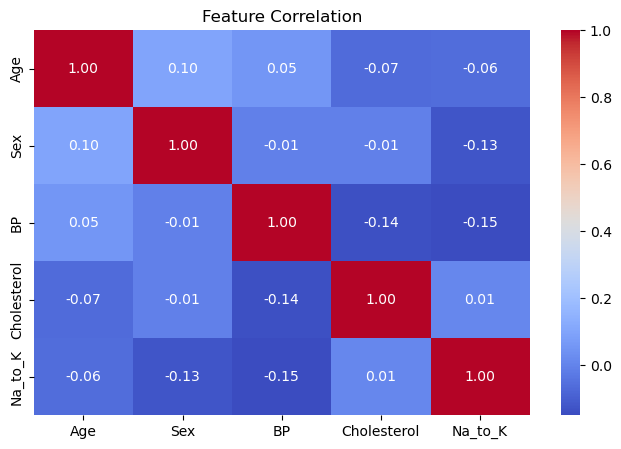

In [37]:
plt.figure(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

Accuracy   : 0.9750
CV Accuracy: 0.9850 +/- 0.0300
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



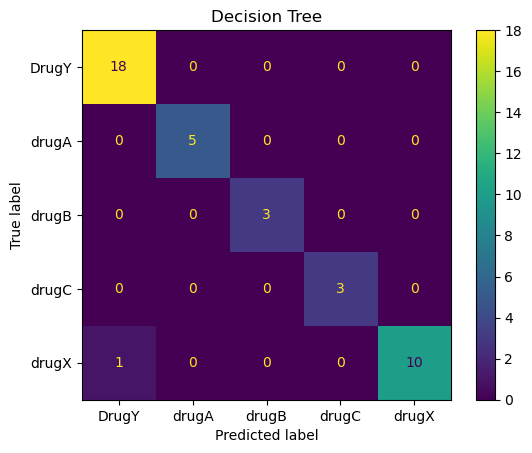

In [38]:
dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(random_state=42))
])

dt_pipe.fit(X_train, y_train)
y_pred = dt_pipe.predict(X_test)
cv     = cross_val_score(dt_pipe, X, y, cv=5, scoring='accuracy')

print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"CV Accuracy: {cv.mean():.4f} +/- {cv.std():.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=le.classes_).plot()
plt.title('Decision Tree')
plt.show()

Best k     : 1
Accuracy   : 0.9000
CV Accuracy: 0.7900 +/- 0.0255
              precision    recall  f1-score   support

       DrugY       0.94      0.83      0.88        18
       drugA       1.00      0.80      0.89         5
       drugB       1.00      1.00      1.00         3
       drugC       0.75      1.00      0.86         3
       drugX       0.85      1.00      0.92        11

    accuracy                           0.90        40
   macro avg       0.91      0.93      0.91        40
weighted avg       0.91      0.90      0.90        40



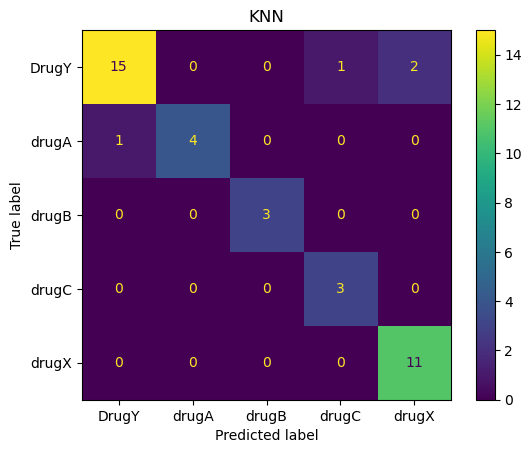

In [39]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier())
])

grid_knn = GridSearchCV(knn_pipe, {'model__n_neighbors': range(1, 21)}, cv=5)
grid_knn.fit(X_train, y_train)
y_pred = grid_knn.predict(X_test)
cv     = cross_val_score(knn_pipe, X, y, cv=5, scoring='accuracy')

print(f"Best k     : {grid_knn.best_params_['model__n_neighbors']}")
print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"CV Accuracy: {cv.mean():.4f} +/- {cv.std():.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=le.classes_).plot()
plt.title('KNN')
plt.show()

Best params: {'model__C': 10, 'model__gamma': 'scale'}
Accuracy   : 0.9000
CV Accuracy: 0.9550 +/- 0.0292
              precision    recall  f1-score   support

       DrugY       0.94      0.83      0.88        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      0.67      0.80         3
       drugX       0.79      1.00      0.88        11

    accuracy                           0.90        40
   macro avg       0.94      0.90      0.91        40
weighted avg       0.91      0.90      0.90        40



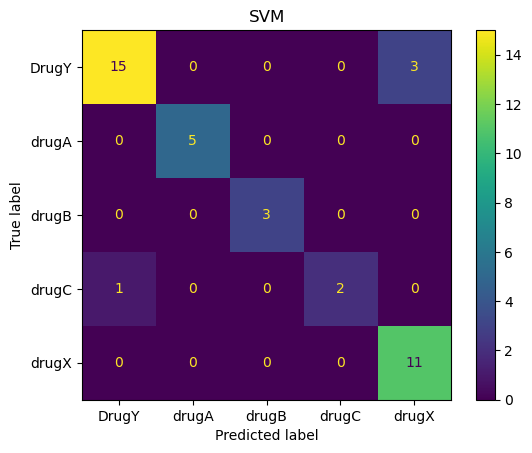

In [40]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', random_state=42))
])

grid_svm = GridSearchCV(svm_pipe,
    {'model__C': [0.1, 1, 10], 'model__gamma': ['scale', 'auto']}, cv=5)
grid_svm.fit(X_train, y_train)
y_pred = grid_svm.predict(X_test)
cv     = cross_val_score(svm_pipe, X, y, cv=5, scoring='accuracy')

print(f"Best params: {grid_svm.best_params_}")
print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"CV Accuracy: {cv.mean():.4f} +/- {cv.std():.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=le.classes_).plot()
plt.title('SVM')
plt.show()

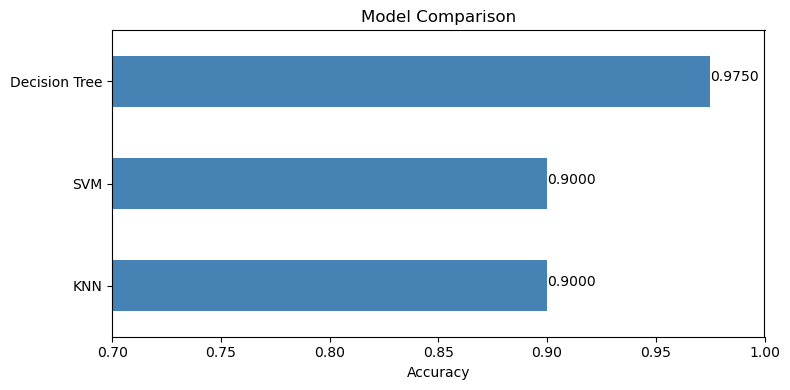

In [41]:
results = {}
for name, pipe in [('Decision Tree', dt_pipe),
                   ('KNN',           grid_knn.best_estimator_),
                   ('SVM',           grid_svm.best_estimator_)]:
    pipe.fit(X_train, y_train)
    results[name] = accuracy_score(y_test, pipe.predict(X_test))

ax = pd.Series(results).sort_values().plot(kind='barh', figsize=(8, 4),
                                            xlim=(0.7, 1.0), color='steelblue')
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', (p.get_width(), p.get_y() + 0.25))
plt.tight_layout()
plt.show()